# 서포트 백터 머신
    - 새로운 데이터가 입력되었을때 기존 데이터를 활용해 분류하는 방법
    - 패턴 인식, 자료 분석 등을 위한 지도 학습 모델로 회귀와 분류 문제 해결에 사용이 되는 알고리즘

- 매개변수
    - C
        - 기본값 : 1.0
        - 규제의 강도의 역수
        - 숫자가 크면 -> 오차를 허용하지 않는다 (과적합 위험)
        - 숫자가 작으면 -> 오차를 어느정도 허용(일반화 위험)
    - kernel (커널 함수의 종류)
        - 기본값 : "rbf"
        - 실제의 데이터가 선형이 아닌 경우 커널 함수를 이용하여 데이터를 고차원 공간으로 매핑하여 직선으로 구분을 가능하게 하는 방법
        - "linear" : 선형 SVM
        - "poly" : 다항식 커널
        - 'rbf' : 가우시안 커널(가장 많이 사용)
        - "sigmoid" : 시그모이드 함수 기반
    - gamma
        - 커널 계수
        - 'linear' 제외한 커널이 선택되었을때 사용
        - 크면 -> 경계가 복잡해짐 (과적합 위험)
        - 작으면 -> 경계가 유연해짐 (일반화 위험)
    - degree
        - 기본값 : 3
        - 다항식 커널의 차수
        - 비선형 데이터의 패턴을 학습할 수 있게 해주는 변수
    - probability
        - 기본값 : False
        - 확률 출력의 여부 -> True인 경우 predict_proba() 함수를 사용 가능
        - 학습할 때 속도가 느려짐
- 주요 속성
    - support_
        - 서포트 백터의 인덱스의 값
        - 전체의 데이터에서 경계선에 딱 붙어 있는 데이터의 인덱스 값
    - support_vectors_
        - support_ 위치(인덱스)의 값이라면 그 값에 해당하는 실제 데이터 값
    - n_support_
        - 클래스(컬럼)별 서포트 백터의 개수
    - coef_
        - 결정 경계의 계수 (linear 커널인 경우에만 사용 가능)
- 메서드
    - fit(x, y) : 학습
    - predict(x) : 예측
    - predict_proba(x) : 예측 확률(probability의 값이 True인 경우)
    - decision_function(x) : 결정 함수의 값(margin과의 거리)
    - score(x, y) : 정확도 평가

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [20]:
df = pd.read_csv("../data/classification.csv")
df.head()

,age,interest,success
0,23.657801,18.859917,0.0
1,22.573729,17.969223,0.0
2,32.553424,29.463651,0.0
3,6.718035,25.704665,1.0
4,14.401919,16.770856,0.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   interest  297 non-null    float64
 2   success   297 non-null    float64
dtypes: float64(3)
memory usage: 7.1 KB


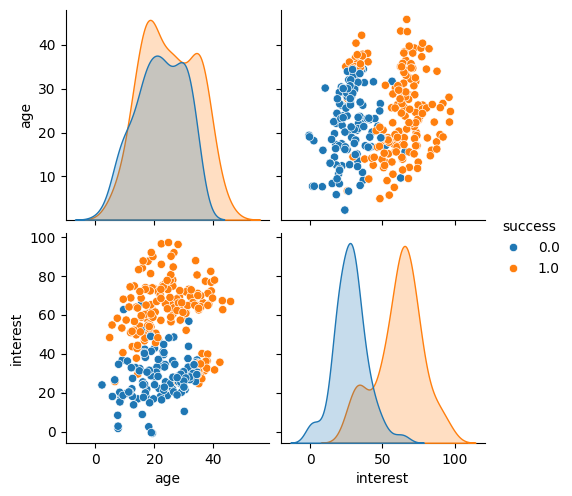

In [22]:
# 데이터 클래스 분포를 그래프 확인
sns.pairplot(
    data = df,
    hue = 'success'
)

In [23]:
# 데이터의 분할 train, test
x = df[['age', 'interest']].values
y = df['success'].values

X_train, X_test, Y_train, Y_test = train_test_split(
    x, y,
    test_size=0.3, stratify=y,
    random_state=42
)

In [24]:
# 스케일러 사용
# SVM은 각각 특성(컬럼)의 스케일에 매우 민감하기 때문에 스케일링 필요
scaler = StandardScaler()

scaler.fit(X_train)

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

In [25]:
# 스케일링이 된 데이터를 기준으로 학습하고 평가
clf = SVC(C=0.5)

In [26]:
clf.fit(X_train_sc, Y_train)

,C,0.5
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
pred = clf.predict(X_test_sc)

cm = confusion_matrix(Y_test, pred)
acc = accuracy_score(Y_test, pred)
prc = precision_score(Y_test, pred)
rcll = recall_score(Y_test, pred)
f1 = f1_score(Y_test, pred)
print("혼동행렬 :", cm)
print('정확도:', round(acc, 2))
print('정밀도 :', round(prc, 2))
print('재현율 :', round(rcll, 2))
print('F1 :', round(f1*100, 2))

혼동행렬 : [[36  3]
 [ 4 47]]
정확도: 0.92
정밀도 : 0.94
재현율 : 0.92
F1 : 93.07


In [29]:
# 스케일링이 되지 않은 원본의 데이터를 이용하여 학습 평가 지표 출력

clf2 = SVC(C=0.5)
clf2.fit(X_train, Y_train)

pred2 = clf2.predict(X_test)

cm_2 = confusion_matrix(Y_test, pred2)
acc_2 = accuracy_score(Y_test, pred2)
prc_2 = precision_score(Y_test, pred2)
rcll_2 = recall_score(Y_test, pred2)
f1_2 = f1_score(Y_test, pred2)
print("혼동행렬 :", cm_2)
print('정확도:', round(acc_2, 2))
print('정밀도 :', round(prc_2, 2))
print('재현율 :', round(rcll_2, 2))
print('F1 :', round(f1_2*100, 2))

혼동행렬 : [[36  3]
 [ 9 42]]
정확도: 0.87
정밀도 : 0.93
재현율 : 0.82
F1 : 87.5


In [30]:
# 분류 분석을 통하여 확인
from sklearn.svm import LinearSVC

C -> 1인 경우 support_vector의 개수는 100
C -> 500인 경우 support_vector의 개수는 97


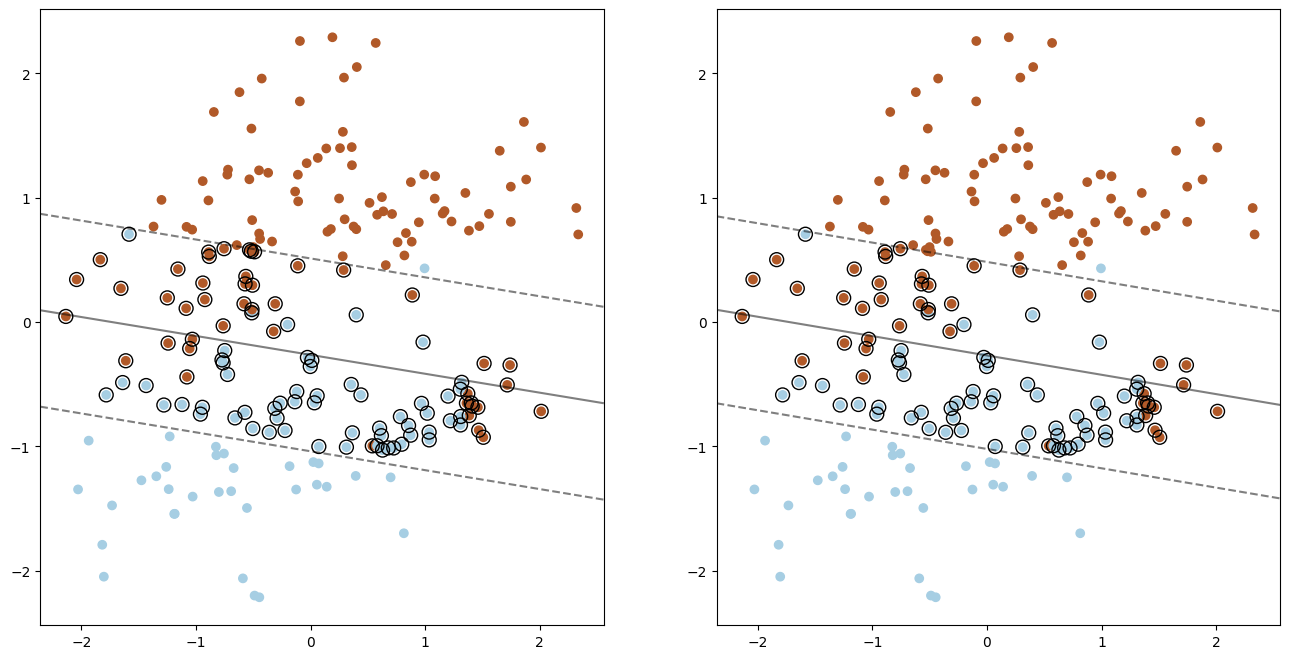

In [ ]:
# 마진 영역을 그래프로 표시

plt.figure(figsize=(16, 8))

for i, c in enumerate([1, 500]):
    # i에서는 [1, 500] 리스트의 위치 값이 순차적으로 대입
    # c에는 [1, 500] 리스트의 값들이 순차적으로 대입
    clf = LinearSVC(C = c, random_state=42)
    clf.fit(X_train_sc, Y_train)

    # decision_function() -> 경계선과의 겨리를 의미
    decision = clf.decision_function(X_train_sc)

    # margin(-1 <= decision_function <= 1) 의 데이터를 support_vector로 간주
    support_vector_indices = np.where(
        np.abs(decision) <= 1 + 1e-15
    )[0]
    support_vector = X_train_sc[support_vector_indices]
    # support_vector의 개수를 출력
    print(f"C -> {c}인 경우 support_vector의 개수는 {len(support_vector)}")

    # sublpot을 이용해서 1행 2열의 영역을 생성
    plt.subplot(1, 2, i+1)

    # 학습 데이터의 산점도 그래프를 생성
    plt.scatter(X_train_sc[:, 0], X_train_sc[:, 1], c = Y_train, cmap=plt.cm.Paired)

    # 현재 좌표축의 정보를 로드
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # 격자(결정 경계) 추가
    xx, yy = np.meshgrid(
        # x축 범위 안에서 50개의 데이터를 생성
        np.linspace(xlim[0], xlim[1], 50),
        # y축 범위 안에서 50개의 데이터를 생성
        np.linspace(ylim[0], ylim[1], 50)
    )

    # 각 격자점에 대한 decision_function의 값을 지정하고 행렬의 크기를 xx와 같게 젼환
    z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)

    # 등고선을 추가
    # 결정 경계와 margin을 생성
    plt.contour(
        xx, yy, z, colors = 'k', levels = [-1, 0, 1],  # levels -> -1, 1은 margins, 0은 결측치
        alpha = 0.5, linestyles = ['--','-', '--']
    )

    # support_vector의 데이터를 동그라미 표시
    plt.scatter(
        support_vector[:, 0], support_vector[:, 1],
        s = 100,   # 크기
        linewidths=1, facecolors = 'none', edgecolors = 'k'

    )

plt.show()

# SVR (Support Vector Regression)
- 서포트 백터 회귀 분석
- 입실론 튜브 안에 들어오는 데이터는 오차로 보지 않는다.
- 튜브 밖의 데이터만 패널티를 부여하는 방식

- 매개변수
    - kernel
        - 커널 함수 선택
        - linear
            - 사용 매개변수 : C, epsilron
            - 고차원 희소데이터, 선형 데이터셋
        - rbf
            - 사용 매개변수 : C, epsilron, gamma
            - 범용, 성능이 우수
        - poly
            - 사용 매개변수 : C, epsilron, degree, gamma
            - 다항적 경계가 자연스러운 데이터
        - sigmoid
            - 사용 매개변수 : C, epsilron, gamma
            - 특수한 경우에 이용, 신경망과 유사 데이터 (연구용 데이터)
    - epsilron : 오차 허용의 폭
    - gamma : 데이터 간 영향의 범위

- 속성
    - dual_coef_ : 쌍대 문제의 알파 값들
    - coef_ : 회귀 계수

In [ ]:
# 랜덤 데이터를 생성
x = np.sort(
    5 * np.random.rand(40, 1), axis=0
)
y = np.sin(x).ravel()

print(x, y)

[[0.04881985]
 [0.12191043]
 [0.1344581 ]
 [0.21605656]
 [0.32730578]
 [0.34617085]
 [0.45710606]
 [0.46606227]
 [0.49030498]
 [0.71846689]
 [0.7496175 ]
 [0.7827211 ]
 [0.83338058]
 [0.86859953]
 [1.2408948 ]
 [1.25479787]
 [1.76559453]
 [1.80263722]
 [1.9193983 ]
 [2.19171652]
 [2.42323611]
 [2.46202407]
 [2.54436457]
 [2.55750882]
 [2.61822243]
 [2.65416487]
 [2.68225846]
 [2.77413515]
 [2.81216839]
 [3.22608788]
 [3.44049313]
 [3.63896009]
 [3.75257738]
 [3.8216734 ]
 [4.01932341]
 [4.28885356]
 [4.40315569]
 [4.69233141]
 [4.71084858]
 [4.86209013]] [ 0.04880046  0.12160868  0.13405332  0.21437954  0.32149301  0.3392983
  0.44135313  0.44937203  0.47089496  0.6582313   0.68135884  0.70521128
  0.74020862  0.76342513  0.94607425  0.95048657  0.98108675  0.97324506
  0.93985117  0.81334345  0.65814822  0.62845751  0.56235254  0.55143533
  0.49980205  0.46835478  0.44335141  0.35924382  0.3234983  -0.08439472
 -0.29446962 -0.47711359 -0.57367431 -0.62885581 -0.76929104 -0.91164163
 -

In [52]:
print(y[:10])

[0.04880046 0.12160868 0.13405332 0.21437954 0.32149301 0.3392983
 0.44135313 0.44937203 0.47089496 0.6582313 ]


In [53]:
# 타깃 데이터(종속변수에 노이즈 추가)
y[::5] += 3*(0.5-np.random.rand(8))
print(y[:10])

[0.81393847 0.12160868 0.13405332 0.21437954 0.32149301 1.55248307
 0.44135313 0.44937203 0.47089496 0.6582313 ]


In [54]:
# 회귀 모델에 (rbf, 선형, 다항)
from sklearn.svm import SVR

In [55]:
svr_rbf = SVR(kernel='rbf', C = 100, gamma = 0.1, epsilon = 0.1)
svr_lin = SVR(kernel='linear', C=100, gamma='auto', epsilon=0.1)
svr_poly = SVR(kernel='poly', C=100, degree=3, gamma='auto', epsilon=0.1, coef0=1)

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [57]:
# 학습
svr_rbf.fit(x, y)
svr_lin.fit(x, y)
svr_poly.fit(x, y)

,kernel,'poly'
,degree,3
,gamma,'auto'
,coef0,1
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [58]:
# 예측 데이터를 생성
pred_rbf = svr_rbf.predict(x)
pred_lin = svr_lin.predict(x)
pred_poly = svr_poly.predict(x)

In [59]:
# 평가 지표를 데이터프레임으로 생성
index = ['RBF', 'Lin', 'Poly']
cols = ['MSE', 'RMSE', 'MAE', 'R2']
result = pd.DataFrame(index = index, columns = cols)
result

,MSE,RMSE,MAE,R2
RBF,NaN,NaN,NaN,NaN
Lin,NaN,NaN,NaN,NaN
Poly,NaN,NaN,NaN,NaN


In [60]:
# 예측 값들을 리스트로 생성
preds = [pred_rbf, pred_lin, pred_poly]

for pred, i in zip(preds, index):
    # pred -> 예측값들 -> 타입이 1차원 배열
    # i -> kernel의 값
    mse = mean_squared_error(y, pred)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)

    result.loc[i, 'MSE'] = mse
    result.loc[i, 'MAE'] = mae
    result.loc[i, 'RMSE'] = rmse
    result.loc[i, 'R2'] = r2

result

,MSE,RMSE,MAE,R2
RBF,0.25173,0.501727,0.295876,0.570478
Lin,0.379298,0.615872,0.50825,0.35281
Poly,0.265065,0.514845,0.281512,0.547723


In [62]:
# boston 데이터를 이용하여 SVR의 RBF, Lin, Poly 모델 중 어떤 것이 성능이 가장 높은가? 확인

# 연습
- csv 폴더 안에 boston 데이터를 로드
- 독립, 종속 변수로 데이터를 나눠준다.
- train, test를 8:2의 비율로 분할
- RBF, Lin, Poly 모델을 생성
- train 데이터를 학습 
- test 데이터를 이용하여 예측
- 각각 모델의 평기 지표를 생성하여 우수한 kernel함수를 선택

In [63]:
boston = pd.read_csv('../csv/boston.csv')

In [65]:
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [77]:
# 독립 변수 / 종속 변수
x = boston.drop('Price', axis = 1).values
y = boston['Price'].values

In [ ]:
# train, test 데이터셋 분할 8:2
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.2 ,random_state=42
)

In [78]:
svr_rbf = SVR(kernel='rbf', C = 100, gamma = 0.1, epsilon = 0.1)
svr_lin = SVR(kernel='linear', C=100, gamma='auto', epsilon=0.1)
svr_poly = SVR(kernel='poly', C=100, degree=3, gamma='auto', epsilon=0.1, coef0=1)

In [ ]:
# 학습
svr_rbf.fit(X_train, Y_train)
svr_lin.fit(X_train, Y_train)
svr_poly.fit(X_train, Y_train)

In [ ]:
pred_rbf = svr_rbf.predict(X_test)
pred_lin = svr_lin.predict(X_test)
pred_poly = svr_poly.predict(X_test)

In [75]:
index = ['RBF', 'Lin', 'Poly']
cols = ['MSE', 'RMSE', 'MAE', 'R2']
result = pd.DataFrame(index = index, columns = cols)
result

,MSE,RMSE,MAE,R2
RBF,NaN,NaN,NaN,NaN
Lin,NaN,NaN,NaN,NaN
Poly,NaN,NaN,NaN,NaN


In [ ]:
# 예측 값들을 리스트로 생성
preds = [pred_rbf, pred_lin, pred_poly]

for pred, i in zip(preds, index):
    # pred -> 예측값들 -> 타입이 1차원 배열
    # i -> kernel의 값
    mse = mean_squared_error(Y_test, pred)
    mae = mean_absolute_error(Y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_test, pred)

    result.loc[i, 'MSE'] = mse
    result.loc[i, 'MAE'] = mae
    result.loc[i, 'RMSE'] = rmse
    result.loc[i, 'R2'] = r2

result

,MSE,RMSE,MAE,R2
RBF,52.838366,7.269,4.530586,0.279481
Lin,29.435909,5.425487,3.140434,0.598604
Poly,53.489816,7.313673,4.511674,0.270598
